In [22]:
import pandas as pd
import numpy as np
import warnings

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, log_loss
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
import optuna

import matplotlib.pyplot as plt
import seaborn as sns


warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [7]:
train = pd.read_csv('/kaggle/input/kaggle-community-olympiad-customer-deflection/train.csv',index_col = 'Id')
test = pd.read_csv('/kaggle/input/kaggle-community-olympiad-customer-deflection/test.csv',index_col = 'Id')

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 404165 entries, 186878 to 345496
Data columns (total 11 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Age                404165 non-null  float64
 1   Gender             404165 non-null  object 
 2   Tenure             404165 non-null  float64
 3   Usage Frequency    404165 non-null  float64
 4   Support Calls      404165 non-null  float64
 5   Payment Delay      404165 non-null  float64
 6   Subscription Type  404165 non-null  object 
 7   Contract Length    404165 non-null  object 
 8   Total Spend        404165 non-null  float64
 9   Last Interaction   404165 non-null  float64
 10  Churn              404165 non-null  float64
dtypes: float64(8), object(3)
memory usage: 37.0+ MB


In [9]:
train.describe()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000,404165.000000
mean,39.709388,31.346693,15.718976,3.830703,13.494808,620.278390,14.603890,0.554776
std,12.681057,17.231919,8.617287,3.134619,8.453428,245.179751,8.609196,0.496991
min,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,29.000000,16.000000,8.000000,1.000000,6.000000,446.670000,7.000000,0.000000
50%,40.000000,32.000000,16.000000,3.000000,13.000000,649.000000,14.000000,1.000000
75%,49.000000,46.000000,23.000000,6.000000,20.000000,824.000000,22.000000,1.000000
max,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [10]:
train.head()

,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
Id,,,,,,,,,,,
186878,23.0,Male,44.0,18.0,0.0,19.0,Basic,Quarterly,846.18,18.0,0.0
414188,19.0,Male,41.0,29.0,1.0,26.0,Basic,Annual,149.04,10.0,1.0
419671,40.0,Male,48.0,11.0,3.0,19.0,Basic,Annual,266.00,9.0,1.0
428771,44.0,Female,58.0,21.0,2.0,27.0,Standard,Quarterly,662.00,16.0,1.0
302010,49.0,Male,24.0,29.0,9.0,9.0,Standard,Monthly,857.00,8.0,1.0


In [11]:
num_cols = train.select_dtypes(include='number').columns.tolist()
cat_cols = train.select_dtypes(include = 'object').columns.tolist()

In [12]:
for col in cat_cols:
    print(f'\n {train[col].value_counts()}')


 Gender
Male      224329
Female    179836
Name: count, dtype: int64

 Subscription Type
Standard    136349
Premium     135993
Basic       131823
Name: count, dtype: int64

 Contract Length
Annual       158947
Quarterly    157957
Monthly       87261
Name: count, dtype: int64


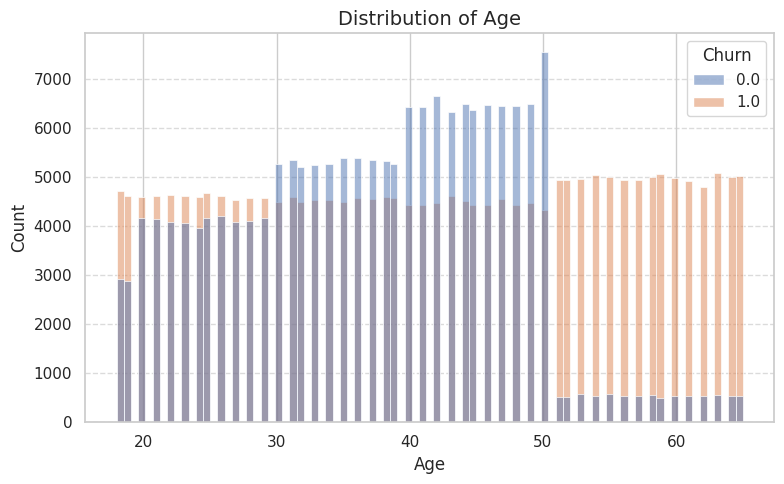

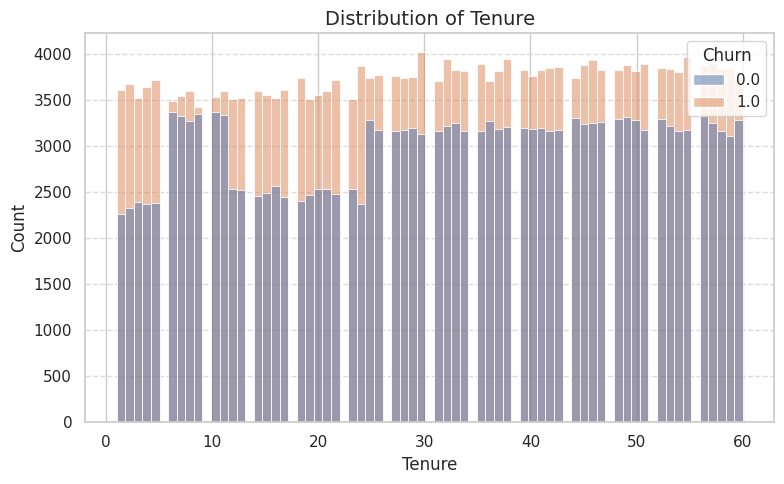

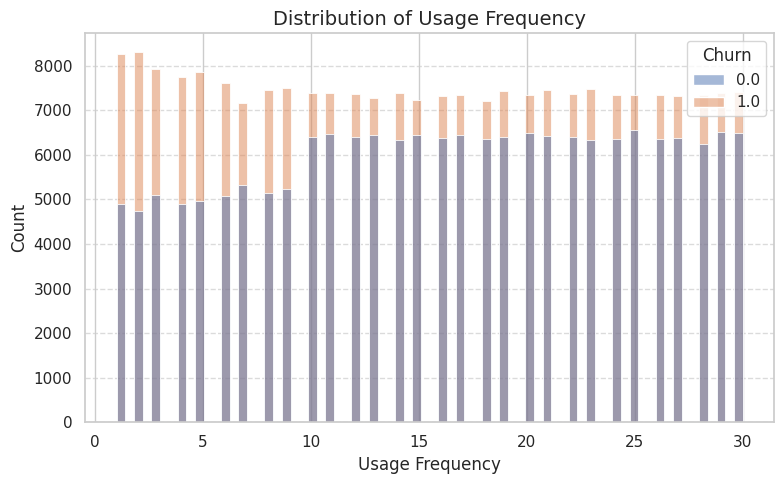

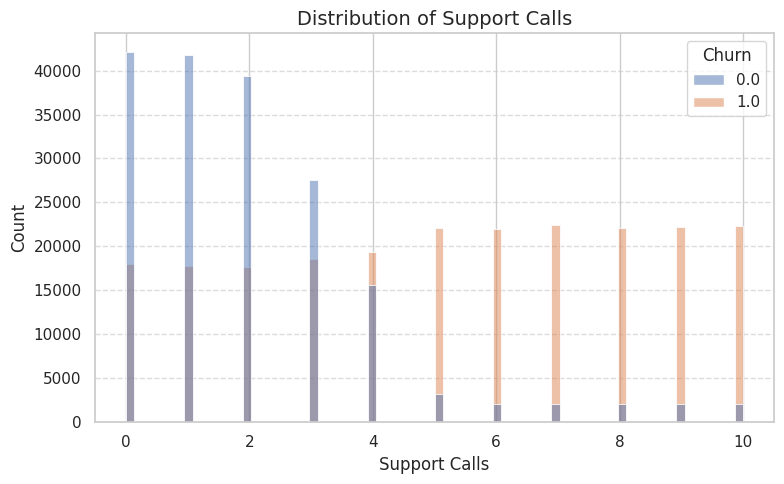

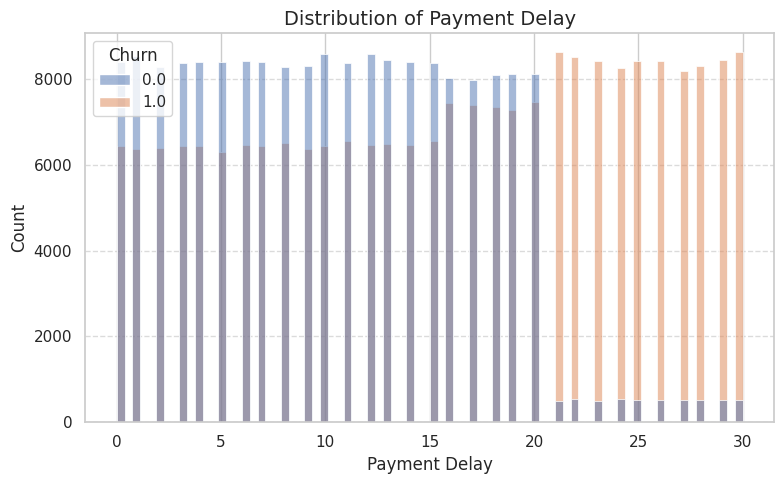

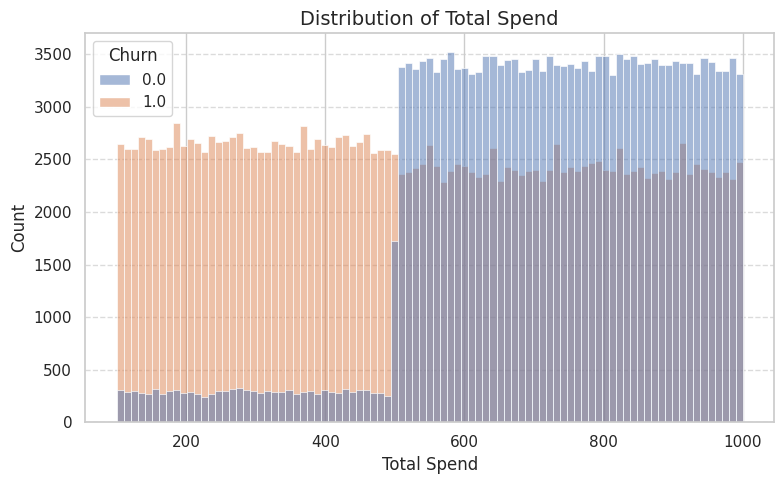

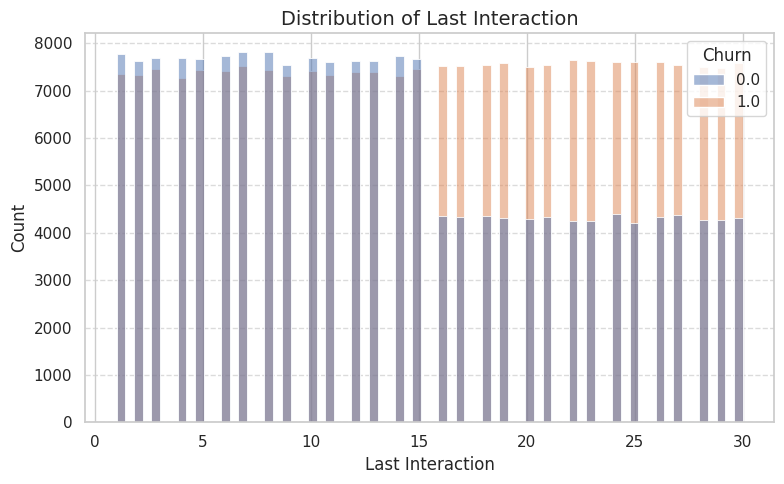

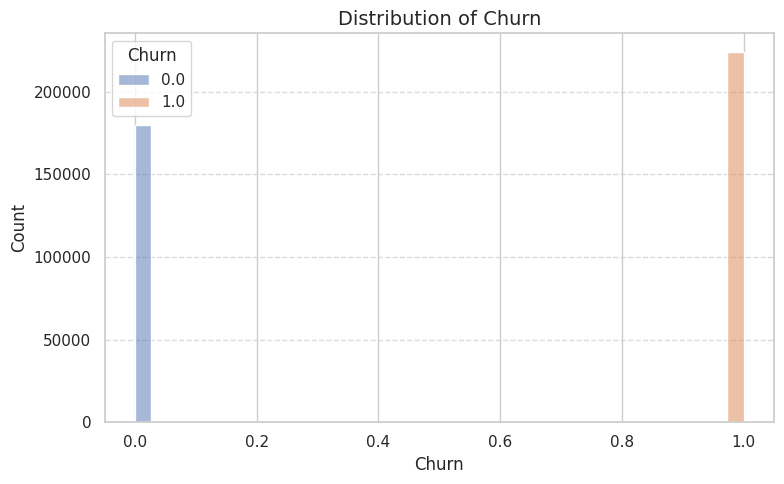

In [14]:
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data=train,x=col,hue='Churn')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

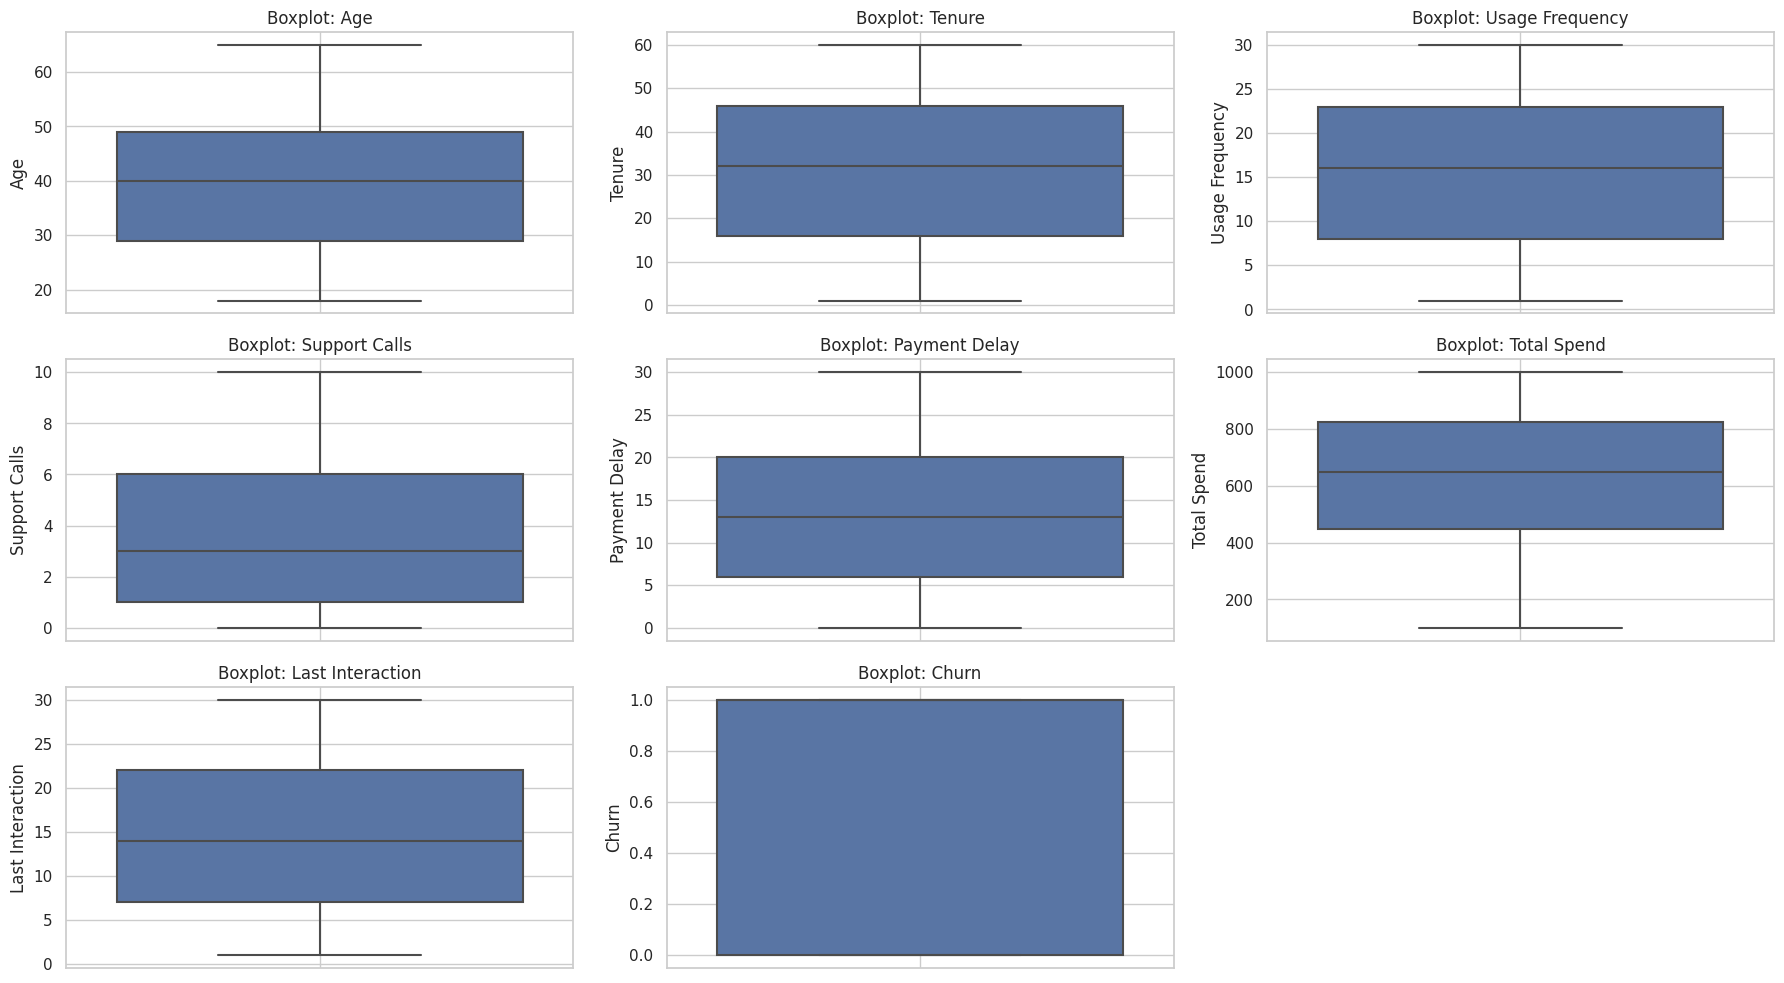

In [15]:
plt.figure(figsize=(18, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(data=train, y=col)
    plt.title(f"Boxplot: {col}")
    plt.grid(True)
plt.tight_layout()
plt.show()

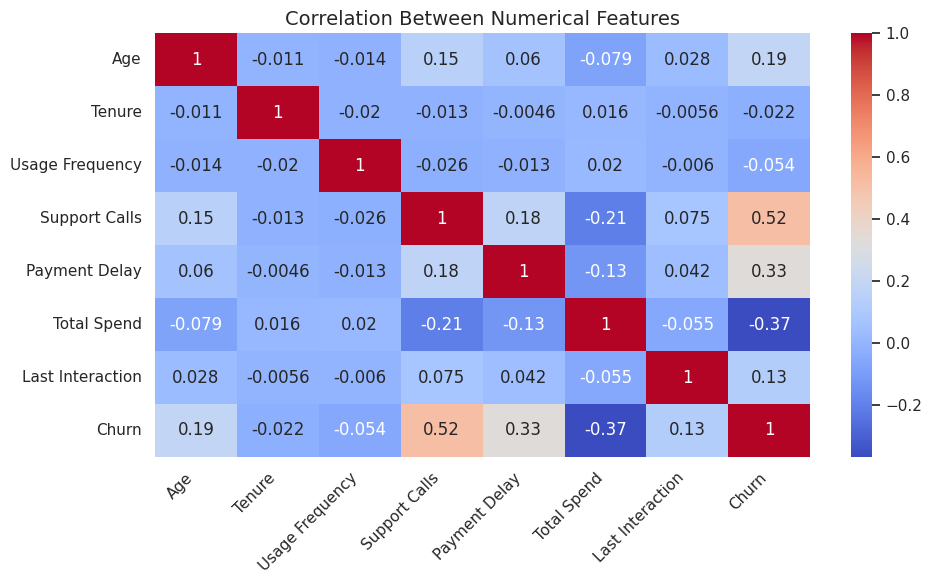

In [16]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    train[num_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [17]:
cat_pipeline = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder()
)

default_num_pipeline = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

preprocessing = ColumnTransformer([
    ('cat', cat_pipeline, make_column_selector(dtype_include=object))
    ],
    remainder=default_num_pipeline)

model = Pipeline(steps=[
    ('preprocessor', preprocessing),
    ('scaler', StandardScaler()),
    ('classifier', XGBClassifier(objective = 'binary:logistic',eval_metric = 'logloss',random_state=42))
])

In [18]:
X = train.drop('Churn', axis=1).copy()
y = train['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=17)

In [19]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder=Pipeline(steps=[('simpleimputer',
                                                              SimpleImputer(strategy='median')),
                                                             ('standardscaler',
                                                              StandardScaler())]),
                                   transformers=[('cat',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder',
                                                                   OneHotEncoder())]),
                                                  <sklearn.compose._column_transformer.make_column_selec...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=None, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

In [23]:
test_pred = model.predict_proba(X_test)[:,1]
test_labels = (test_pred > 0.5).astype(int)
accuracy = accuracy_score(y_test, test_labels)
roc_auc = roc_auc_score(y_test, test_pred)
log_loss = log_loss(y_test, test_pred)
print(f'Accuracy: {accuracy}')
print(f'ROC AUC Score: {roc_auc}')
print(f'Log Loss: {log_loss}')
print(classification_report(y_test, test_labels))

Accuracy: 0.9342595227196813
ROC AUC Score: 0.9527514809329934
Log Loss: 0.1946361052265705
              precision    recall  f1-score   support

         0.0       0.99      0.86      0.92     35933
         1.0       0.90      0.99      0.94     44900

    accuracy                           0.93     80833
   macro avg       0.94      0.93      0.93     80833
weighted avg       0.94      0.93      0.93     80833



[I 2025-08-27 21:12:59,350] A new study created in memory with name: no-name-d11b1c99-5f3d-45ea-b7ea-c18b205d047b
[W 2025-08-27 21:13:01,650] Trial 0 failed with parameters: {'n_estimators': 548, 'learning_rate': 0.029573577957374548, 'max_depth': 4, 'subsample': 0.8551764230579018, 'colsample_bytree': 0.6707455482579752} because of the following error: ValueError('\nAll the 3 fits failed.\nIt is very likely that your model is misconfigured.\nYou can try to debug the error by setting error_score=\'raise\'.\n\nBelow are more details about the failures:\n--------------------------------------------------------------------------------\n2 fits failed with the following error:\nTraceback (most recent call last):\n  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score\n    estimator.fit(X_train, y_train, **fit_params)\n  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 405, in fit\n    self._final_estimator

ValueError: 
All the 3 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/pipeline.py", line 405, in fit
    self._final_estimator.fit(Xt, y, **fit_params_last_step)
  File "/usr/local/lib/python3.11/dist-packages/xgboost/core.py", line 730, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboost/sklearn.py", line 1519, in fit
    self._Booster = train(
                    ^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/xgboos

In [42]:
submission = pd.read_csv('/kaggle/input/kaggle-community-olympiad-customer-deflection/test.csv')
submission['Churn'] = model.predict_proba(test)[:,1]
submission[['Id','Churn']].to_csv("submission.csv", index=False)